# Heart Disease Prediction – Pipeline Huấn luyện Mô hình

**Môn học:** Khai khoáng Dữ liệu (Data Mining)

Pipeline gồm **4 giai đoạn chuẩn**, tuân thủ nguyên tắc **không data leakage**:

| # | Giai đoạn | Nội dung |
|---|-----------|----------|
| 1 | Tiền xử lý | Encode → Split → Scale đúng thứ tự |
| 2 | K-Fold CV | So sánh khách quan 6 mô hình |
| 3 | Test Set Eval | Báo cáo chính thức trên tập Test |
| 4 | Retrain & Lưu | Tạo artifacts để deploy API |

In [1]:
import os

# ==================================================
# CẤU HÌNH MÔI TRƯỜNG (Tự động phát hiện Colab / Local)
# ==================================================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/Data Mining/Project/disease_prediction_2026_clean.csv'
    SAVE_DIR  = '/content/drive/MyDrive/Data Mining/Project/Saved_Models/'
    print('Moi truong: Google Colab')
except Exception:
    DATA_PATH = '../data/disease_prediction_2026.csv'
    SAVE_DIR  = '../models/'
    print('Moi truong: Local')

os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Du lieu  : {DATA_PATH}')
print(f'Luu model: {SAVE_DIR}')

Mounted at /content/drive
Moi truong: Google Colab
Du lieu  : /content/drive/MyDrive/Data Mining/Project/disease_prediction_2026_clean.csv
Luu model: /content/drive/MyDrive/Data Mining/Project/Saved_Models/


In [4]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.base            import clone
from sklearn.metrics         import (accuracy_score, recall_score, f1_score, classification_report,
                                      confusion_matrix, ConfusionMatrixDisplay)
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from xgboost                 import XGBClassifier

print('Import thu vien thanh cong!')

Import thu vien thanh cong!


## Phần 1: Tiền xử lý & Chia tập Dữ liệu

> **Nguyên tắc chống Data Leakage (đặc biệt quan trọng):**
> 1. **Chia tập TRƯỚC** (`train_test_split`) trước khi xử lý features
> 2. **Fit encoder/scaler CHỈ trên Train set** → transform cả Train lẫn Test

In [3]:
# =====================================================================
# PHẦN 1: TIỀN XỬ LÝ & CHIA TẬP DỮ LIỆU (KHÔNG DATA LEAKAGE)
# =====================================================================

# Đọc dữ liệu
df = pd.read_csv(DATA_PATH)
# Cấu hình cột – thứ tự PHẢI khớp với app.py (quan trọng cho deploy)
CATEGORICAL_COLS = ['gender', 'smoking', 'alcohol_consumption',
                    'physical_activity', 'family_history']
NUMERICAL_COLS   = ['age', 'glucose_mg_dl', 'cholesterol_mg_dl',
                    'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate']
FEATURE_ORDER    = ['age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl',
                    'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate',
                    'smoking', 'alcohol_consumption',
                    'physical_activity', 'family_history']

X = df.drop('disease', axis=1)[FEATURE_ORDER].copy()
y = df['disease']

# ── BƯỚC 1: Mã hóa nhãn mục tiêu ──────────────────────────────────
# fit trên toàn bộ y là hợp lệ: nhãn là global, biết trước
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
class_map = dict(zip(le_target.classes_,
                     le_target.transform(le_target.classes_)))
print(f'Classes: {class_map}')

# ── BƯỚC 2: CHIA TẬP TRƯỚC khi xử lý features ────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Train : {X_train_raw.shape} | Test: {X_test_raw.shape}')
u_vals, u_counts = np.unique(y_train, return_counts=True)
print(f'y_train phan phoi: {dict(zip(u_vals, u_counts))}')

# ── BƯỚC 3: Mã hóa Categorical – CHỈ FIT TRÊN X_train_raw ───────
feature_encoders = {}
X_train_enc = X_train_raw.copy()
X_test_enc  = X_test_raw.copy()

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_raw[col])  # fit+transform tren Train
    X_test_enc[col]  = le.transform(X_test_raw[col])        # chi transform tren Test
    feature_encoders[col] = le

print(f'\nMa hoa {len(CATEGORICAL_COLS)} cot categorical (fit chi tren Train)')
print('(Scaling se thuc hien noi bo trong tung fold o Phan 3)')
print()
print('X_train_enc (3 dong dau):')
print(X_train_enc.head(3).to_string())

Classes: {'No': np.int64(0), 'Yes': np.int64(1)}
Train : (798, 12) | Test: (200, 12)
y_train phan phoi: {np.int64(0): np.int64(397), np.int64(1): np.int64(401)}

Ma hoa 5 cot categorical (fit chi tren Train)
(Scaling se thuc hien noi bo trong tung fold o Phan 3)

X_train_enc (3 dong dau):
     age  gender  glucose_mg_dl  cholesterol_mg_dl  systolic_bp  diastolic_bp   bmi  heart_rate  smoking  alcohol_consumption  physical_activity  family_history
157   67       0            132                223          133          87.0  25.6        80.0        1                    1                  0               0
928   45       1            130                275          132          93.0  35.5        68.0        0                    1                  0               1
244   18       1            115                174          117          89.0  25.4        72.0        1                    0                  1               1


## Phần 2: Huấn luyện & So sánh Mô hình (K-Fold CV)

- **Stratified K-Fold (k=5)**: Đảm bảo phân phối nhãn đồng đều giữa các fold
- **`clone(model)`**: Tạo bản sao model mới mỗi fold, tránh carry-over state
- **Scale nội bộ mỗi fold**: Scaler chỉ fit trên fold-train, tránh leakage tuyệt đối

In [ ]:
# =====================================================================
# PHẦN 2: STRATIFIED K-FOLD CROSS VALIDATION
# =====================================================================
K_SPLITS = 5
skf = StratifiedKFold(n_splits=K_SPLITS, shuffle=True, random_state=42)

# ── Định nghĩa Base Models ──────────────────────────────────
BASE_MODELS = {
    'KNN'          : KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    'SVM'          : SVC(kernel='rbf', C=1.0, gamma='scale',
                         probability=True, random_state=42),
    'Decision_Tree': DecisionTreeClassifier(criterion='gini',
                                            max_depth=5, random_state=42),
    'Random_Forest': RandomForestClassifier(n_estimators=100,
                                            random_state=42, n_jobs=-1),
    'XGBoost'      : XGBClassifier(n_estimators=100, learning_rate=0.1,
                                   objective='binary:logistic',
                                   eval_metric='logloss',
                                   random_state=42, n_jobs=-1),
}
BASE_MODELS['Ensemble_Voting'] = VotingClassifier(
    estimators=[
        ('knn', BASE_MODELS['KNN']),
        ('svm', BASE_MODELS['SVM']),
        ('rf' , BASE_MODELS['Random_Forest']),
        ('xgb', BASE_MODELS['XGBoost']),
    ],
    voting='soft', n_jobs=-1
)

cv_results = {name: {'acc': [], 'recall': [], 'f1': []} for name in BASE_MODELS}
fold_border = '=' * 22
print(f'Bat dau {K_SPLITS}-Fold CV (clone model moi fold – khong ro ri state)\n')

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_enc, y_train), 1):
    print(f'{fold_border} FOLD {fold}/{K_SPLITS} {fold_border}')

    X_fold_tr = X_train_enc.iloc[train_idx].copy()
    X_fold_vl = X_train_enc.iloc[val_idx].copy()
    y_fold_tr = y_train[train_idx]
    y_fold_vl = y_train[val_idx]

    # Scale NOI BO moi fold: fit_transform tren fold-train, transform tren fold-val
    fold_scaler = StandardScaler()
    X_fold_tr[NUMERICAL_COLS] = fold_scaler.fit_transform(X_fold_tr[NUMERICAL_COLS])
    X_fold_vl[NUMERICAL_COLS] = fold_scaler.transform(X_fold_vl[NUMERICAL_COLS])

    for name, model in BASE_MODELS.items():
        m = clone(model)          # clone: tao ban sao model moi, tranh carry-over state
        m.fit(X_fold_tr, y_fold_tr)
        y_pred = m.predict(X_fold_vl)
        acc = accuracy_score(y_fold_vl, y_pred)
        rec = recall_score(y_fold_vl, y_pred)
        f1 = f1_score(y_fold_vl, y_pred)

        cv_results[name]['acc'].append(acc)
        cv_results[name]['recall'].append(rec)
        cv_results[name]['f1'].append(f1)

        print(f'  {name:<20} | Acc: {acc*100:.2f}% | Recall: {rec*100:.2f}%')

# ── Bảng tổng hợp kết quả ─────────────────────────────────
divider = '=' * 90
print('\n' + divider)
print(('BANG TONG HOP ' + str(K_SPLITS) + '-FOLD CV').center(90))
print(divider)

# Tiêu đề các cột
print(f' {"Mo Hinh":<18} | {"Avg Accuracy (Std)":<20} | {"Avg Recall (Std)":<20} | {"Avg F1-Score (Std)":<20}')
print('-' * 90)

# 💡 Tiêu chí "Model tốt nhất": Dùng F1-Score thay vì Accuracy để phù hợp với bài toán Y tế
best_name = max(cv_results, key=lambda n: np.mean(cv_results[n]['f1']))
best_f1_avg = np.mean(cv_results[best_name]['f1']) * 100

for name, metrics in cv_results.items():
    # Tính toán Accuracy
    acc_avg = np.mean(metrics['acc']) * 100
    acc_std = np.std(metrics['acc']) * 100

    # Tính toán Recall
    rec_avg = np.mean(metrics['recall']) * 100
    rec_std = np.std(metrics['recall']) * 100

    # Tính toán F1-Score
    f1_avg = np.mean(metrics['f1']) * 100
    f1_std = np.std(metrics['f1']) * 100

    # Đánh dấu mô hình vô địch
    mark = '  <-- BEST' if name == best_name else ''

    # Định dạng chuỗi hiển thị theo form: "95.50% (±1.20)"
    acc_str = f"{acc_avg:>6.2f}% (±{acc_std:<4.2f})"
    rec_str = f"{rec_avg:>6.2f}% (±{rec_std:<4.2f})"
    f1_str  = f"{f1_avg:>6.2f}% (±{f1_std:<4.2f})"

    # In ra từng hàng
    print(f' {name:<18} | {acc_str:<20} | {rec_str:<20} | {f1_str:<20}{mark}')

print(divider)
print(f'\n🏆 Mo hinh tot nhat (theo F1-Score): [{best_name}] – F1 Avg = {best_f1_avg:.2f}%')

Bat dau 5-Fold CV (clone model moi fold – khong ro ri state)

====================== FOLD 1/5 ======================
  KNN                  | Acc: 73.12% | Recall: 60.49%
  SVM                  | Acc: 80.00% | Recall: 77.78%
  Decision_Tree        | Acc: 78.12% | Recall: 62.96%
  Random_Forest        | Acc: 89.38% | Recall: 87.65%
  XGBoost              | Acc: 95.62% | Recall: 96.30%
  Ensemble_Voting      | Acc: 87.50% | Recall: 83.95%
====================== FOLD 2/5 ======================
  KNN                  | Acc: 80.62% | Recall: 77.50%
  SVM                  | Acc: 84.38% | Recall: 85.00%
  Decision_Tree        | Acc: 77.50% | Recall: 86.25%
  Random_Forest        | Acc: 89.38% | Recall: 93.75%
  XGBoost              | Acc: 93.12% | Recall: 95.00%
  Ensemble_Voting      | Acc: 92.50% | Recall: 93.75%
====================== FOLD 3/5 ======================
  KNN                  | Acc: 76.88% | Recall: 75.00%
  SVM                  | Acc: 85.00% | Recall: 85.00%
  Decision_Tree  

In [7]:
# Biểu đồ so sánh Accuracy các mô hình
model_names = list(cv_results.keys())
avg_accs    = [np.mean(v) * 100 for v in cv_results.values()]
std_accs    = [np.std(v)  * 100 for v in cv_results.values()]
colors      = ['#64B5F6', '#81C784', '#FFB74D', '#E57373', '#BA68C8', '#4DB6AC']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(model_names, avg_accs, yerr=std_accs, capsize=5,
              color=colors, edgecolor='white', linewidth=1.5, alpha=0.92)

chart_title = f'So sanh Accuracy – {K_SPLITS}-Fold Cross Validation'
ax.set_title(chart_title, fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy trung binh (%)', fontsize=12)
ax.set_ylim([60, 106])
ax.axhline(90, color='red', linestyle='--', alpha=0.45, label='Nguong 90%')
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=15)

for bar, acc, std in zip(bars, avg_accs, std_accs):
    label_text = f'{acc:.1f}%'
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.4,
            label_text, ha='center', va='bottom',
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for /: 'dict' and 'int'

## Phần 4: Đánh giá Mô hình tốt nhất trên Test Set

Tập Test (20%) được giữ **hoàn toàn cô lập** từ đầu.  
Đây là lần đánh giá **duy nhất** để báo cáo kết quả chính thức cho đồ án.

Huan luyen [XGBoost] tren toan bo Train (80%) -> danh gia Test (20%)...

  Test Set Accuracy: 95.00%

Classification Report:

              precision    recall  f1-score   support

          No       0.98      0.92      0.95       100
         Yes       0.92      0.98      0.95       100

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



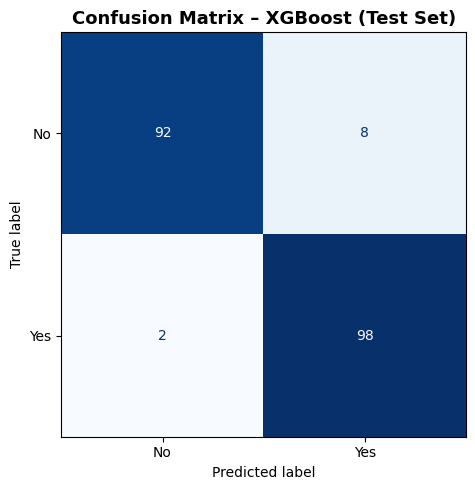

In [ ]:
# =====================================================================
# PHẦN 3: ĐÁNH GIÁ TRÊN TEST SET ĐỘC LẬP (BÁO CÁO CHÍNH THỨC)
# =====================================================================
print(f'Huan luyen [{best_name}] tren toan bo Train (80%) -> danh gia Test (20%)...\n')

# Scale: fit tren X_train_enc (80%), transform ca train lan test
eval_scaler    = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled  = X_test_enc.copy()
X_train_scaled[NUMERICAL_COLS] = eval_scaler.fit_transform(X_train_enc[NUMERICAL_COLS])
X_test_scaled[NUMERICAL_COLS]  = eval_scaler.transform(X_test_enc[NUMERICAL_COLS])

# Clone model (khong tai su dung object tu K-Fold)
best_model_eval = clone(BASE_MODELS[best_name])
best_model_eval.fit(X_train_scaled, y_train)
y_pred_test = best_model_eval.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred_test)
print('=' * 55)
print(f'  Test Set Accuracy: {test_acc * 100:.2f}%')
print('=' * 55)
print()
target_names = list(le_target.classes_)
print('Classification Report:\n')
print(classification_report(y_test, y_pred_test, target_names=target_names))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm      = confusion_matrix(y_test, y_pred_test)
disp    = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
cm_title = f'Confusion Matrix – {best_name} (Test Set)'
ax.set_title(cm_title, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Phần 4: Retrain 100% Dữ liệu & Lưu Model (Deploy)

Retrain mô hình trên **100% dữ liệu** để tận dụng toàn bộ thông tin trước khi deploy.

Artifacts lưu ra **tương thích đầy đủ với `app.py`** (FastAPI):
- `best_binary_disease_model.json` – XGBoost native format
- `final_scaler.pkl` – StandardScaler đã fit trên 100% data
- `feature_encoders.pkl` – Dict các LabelEncoder cho từng categorical feature
- `target_encoder.pkl` – LabelEncoder cho nhãn mục tiêu

In [ ]:
# =====================================================================
# PHẦN 4: RETRAIN 100% DỮ LIỆU & LƯU ARTIFACTS (DEPLOY)
# =====================================================================
print(f'Retrain [{best_name}] tren 100% du lieu ({len(X):,} mau)...\n')

# Bước A: Encode categorical trên TOÀN BỘ X (cho production)
feature_encoders_final = {}
X_full_enc = X.copy()
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    X_full_enc[col] = le.fit_transform(X[col])
    feature_encoders_final[col] = le

# Bước B: Scale numerical trên TOÀN BỘ X
final_scaler = StandardScaler()
X_full_enc[NUMERICAL_COLS] = final_scaler.fit_transform(X_full_enc[NUMERICAL_COLS])

# Bước C: Retrain mô hình tốt nhất (clone từ đầu)
final_model = clone(BASE_MODELS[best_name])
final_model.fit(X_full_enc, y_encoded)
print(f'Huan luyen xong tren {len(X_full_enc):,} mau (100%)\n')

# ── LƯ͠U ARTIFACTS ───────────────────────────────────────────
# 1. Model (XGBoost JSON nếu best model là XGBoost, PKL nếu khác)
if best_name == 'XGBoost':
    model_file = 'best_binary_disease_model.json'
    model_path = os.path.join(SAVE_DIR, model_file)
    final_model.save_model(model_path)
    print(f'[OK] Model (XGBoost JSON) : {model_file}')
else:
    model_file = 'best_binary_disease_model.pkl'
    model_path = os.path.join(SAVE_DIR, model_file)
    joblib.dump(final_model, model_path)
    print(f'[OK] Model (Joblib PKL)   : {model_file}')

# 2. Scaler
scaler_path = os.path.join(SAVE_DIR, 'final_scaler.pkl')
joblib.dump(final_scaler, scaler_path)
print('[OK] Scaler               : final_scaler.pkl')

# 3. Feature Encoders (dict)
enc_path = os.path.join(SAVE_DIR, 'feature_encoders.pkl')
joblib.dump(feature_encoders_final, enc_path)
print('[OK] Feature Encoders     : feature_encoders.pkl')

# 4. Target Encoder
tgt_path = os.path.join(SAVE_DIR, 'target_encoder.pkl')
joblib.dump(le_target, tgt_path)
print('[OK] Target Encoder       : target_encoder.pkl')

print(f'\nLuu tai: {SAVE_DIR}')

Retrain [XGBoost] tren 100% du lieu (998 mau)...

Huan luyen xong tren 998 mau (100%)

[OK] Model (XGBoost JSON) : best_binary_disease_model.json
[OK] Scaler               : final_scaler.pkl
[OK] Feature Encoders     : feature_encoders.pkl
[OK] Target Encoder       : target_encoder.pkl

Luu tai: /content/drive/MyDrive/Data Mining/Project/Saved_Models/


In [10]:
# ── Xác nhận artifacts đã lưu ────────────────────────────────
print('Kiem tra artifacts:\n')
check_files = [
    'best_binary_disease_model.json',
    'final_scaler.pkl',
    'feature_encoders.pkl',
    'target_encoder.pkl',
]
all_ok = True
for fname in check_files:
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  [OK]      {fname:<42} ({size_kb:>8.1f} KB)')
    else:
        print(f'  [MISSING] {fname:<42}')
        all_ok = False

print()
if all_ok:
    print('Tat ca artifacts OK! San sang deploy.')
else:
    print('Mot so file bi thieu, kiem tra lai!')

print()
print('=' * 60)
print('PIPELINE HOAN TAT'.center(60))
print('=' * 60)

Kiem tra artifacts:

  [OK]      best_binary_disease_model.json             (   380.0 KB)
  [OK]      final_scaler.pkl                           (     1.1 KB)
  [OK]      feature_encoders.pkl                       (     1.4 KB)
  [OK]      target_encoder.pkl                         (     0.5 KB)

Tat ca artifacts OK! San sang deploy.

                     PIPELINE HOAN TAT                      
